In [1]:
import os
import pandas as pd
import numpy as np
import time
from collections import Counter

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import seaborn as sns

import traceback
import warnings
warnings.filterwarnings("ignore")

In [2]:
#setting basic requirements of seaborn,matplotlib

sns.set_theme(
    style = "whitegrid",
    palette = "colorblind",
    context = "notebook"
)

plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "axes.titlesize" : 12,
    "axes.labelsize" : 8,
    "axes.grid" : True,
    "font.size" : 4,
    "lines.linewidth" : 3
})

In [3]:
np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4f}".format)

In [4]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/features/feature_engineering.py"

In [5]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.features import feature_engineering

In [6]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/interim")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates=["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
0,2020-01-01 00:00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0
1,2020-01-01 01:00:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0
2,2020-01-01 02:00:00,6.0000,93,0.0000,7.8000,12.7000,1004.6000,1019.4000,0
3,2020-01-01 03:00:00,5.8000,94,0.0000,7.6000,12.3000,1004.6000,1019.5000,0
4,2020-01-01 04:00:00,5.7000,95,0.0000,7.6000,13.1000,1004.7000,1019.6000,0


In [7]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               52608 non-null  datetime64[ns]
 1   Temperature        52608 non-null  float64       
 2   Relative_humidity  52608 non-null  int64         
 3   Rain               52608 non-null  float64       
 4   Soil_temperature   52608 non-null  float64       
 5   Wind_speed         52608 non-null  float64       
 6   Surface_pressure   52608 non-null  float64       
 7   Pressure_msl       52608 non-null  float64       
 8   is_day             52608 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 3.6 MB


In [8]:
weather_data.set_index("Date", inplace = True)
weather_data = weather_data.resample("W").sum()
weather_data = weather_data.reset_index()

In [9]:
weather_data = feature_engineering.add_features(weather_data)

In [10]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               314 non-null    datetime64[ns]
 1   Temperature                        314 non-null    float64       
 2   Relative_humidity                  314 non-null    int64         
 3   Rain                               314 non-null    float64       
 4   Soil_temperature                   314 non-null    float64       
 5   Wind_speed                         314 non-null    float64       
 6   Surface_pressure                   314 non-null    float64       
 7   Pressure_msl                       314 non-null    float64       
 8   is_day                             314 non-null    int64         
 9   Rolling Mean of Temperature        291 non-null    float64       
 10  Rolling Mean of Relative_humidity  291

In [11]:
num_cols = weather_data.select_dtypes(include = ["float64","int64"]).columns

weather_data[num_cols].describe()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling std of Relative_humidity,Rolling std of Rain,Rolling std of Soil_temperature,Rolling std of Wind_speed,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Rolling std of is_day,Sine_Day_of-year,Cose_Day_of-year,is_weekend
count,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,291.0000,291.0000,...,291.0000,291.0000,291.0000,291.0000,291.0000,291.0000,291.0000,314.0000,314.0000,314.0000
mean,4165.1720,11276.5796,22.4914,4351.8201,2552.4373,166562.0535,168868.0500,84.7420,4239.8702,11224.8885,...,2523.2091,32.7876,794.9205,597.7856,884.5732,926.7441,7.1660,0.0002,0.0036,1.0000
std,1078.6236,2982.6090,39.4742,1099.0318,647.4539,6050.6604,6138.4168,10.1733,643.8368,1505.2226,...,904.0798,19.1811,305.8317,103.3922,1224.5757,1240.3837,1.5530,0.7070,0.7095,0.0000
min,855.4000,3287.0000,0.0000,954.6000,613.8000,72100.0000,73143.5000,30.0000,3132.5375,8533.8333,...,1146.7227,1.6082,207.3964,413.6051,379.8930,415.1489,4.9840,-1.0000,-1.0000,1.0000
25%,3261.1250,9459.0000,0.0000,3396.2750,2128.9250,166083.3250,168336.1750,77.0000,3607.0854,9750.3542,...,1640.6474,12.8420,577.8605,525.2184,604.6464,642.1541,5.7028,-0.6995,-0.6964,1.0000
50%,4617.1500,11985.5000,2.3000,4789.1000,2503.0000,166879.9000,169163.4500,84.0000,4302.3667,11489.7083,...,2653.2957,34.8360,819.6504,590.5607,818.2773,862.3341,7.1108,0.0043,0.0043,1.0000
75%,4941.9000,13694.2500,31.2500,5130.6750,2984.8750,168009.1250,170380.5250,96.0000,4848.6854,12701.8750,...,3337.1631,45.7172,995.8057,652.1139,961.4168,1011.5305,8.6450,0.6979,0.7147,1.0000
max,6361.3000,15054.0000,343.7000,6628.7000,4660.2000,169186.9000,171646.4000,98.0000,5235.5875,13447.0833,...,4433.8975,73.4846,1549.0392,881.3799,19429.2963,19692.4636,13.4196,1.0000,1.0000,1.0000


## **Exploratory Data Analysis (EDA)**

In [16]:
weather_data.set_index("Date",inplace = True)

In [17]:
weather_data.head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling std of Pressure_msl,Rolling std of is_day,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-05,1675.7000,10281,8.8000,1710.7000,1951.2000,120490.3000,122221.1000,50,NaN,NaN,...,NaN,NaN,5,0.0860,0.9963,6,5,1,1,1
2020-01-12,2258.3000,13833,12.8000,2419.6000,2646.2000,168485.5000,170909.7000,72,NaN,NaN,...,NaN,NaN,12,0.2051,0.9787,6,12,1,1,1
2020-01-19,2463.7000,14878,50.5000,2553.9000,2122.5000,168147.1000,170556.6000,77,NaN,NaN,...,NaN,NaN,19,0.3213,0.9470,6,19,1,1,1
2020-01-26,2210.6000,13276,0.0000,2361.7000,2616.4000,168428.6000,170855.0000,77,NaN,NaN,...,NaN,NaN,26,0.4328,0.9015,6,26,1,1,1
2020-02-02,2494.4000,13033,8.4000,2608.1000,3100.4000,168131.3000,170538.7000,77,NaN,NaN,...,NaN,NaN,33,0.5380,0.8429,6,2,2,1,1


In [18]:
weather_data.resample("W").max().sort_values(by="Temperature", ascending=False).head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling std of Pressure_msl,Rolling std of is_day,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2024-06-16,6361.3000,4279,0.0000,6628.7000,3242.0000,165409.4000,167601.3000,98,4137.4000,8891.0000,...,1209.5832,9.2806,168,0.2470,-0.9690,6,16,6,2,1
2024-06-02,6250.4000,5989,0.0000,6538.1000,2720.6000,165224.8000,167420.2000,98,3838.1208,9504.2500,...,1137.5277,9.4216,154,0.4712,-0.8820,6,2,6,2,1
2023-06-18,6193.4000,5836,0.0000,6347.8000,4660.2000,165400.1000,167599.9000,98,4100.8542,9075.6250,...,998.9035,9.2873,169,0.2303,-0.9731,6,18,6,2,1
2024-06-23,5949.4000,8054,12.1000,6426.2000,3077.9000,165308.7000,167517.3000,98,4283.7042,8630.3750,...,1248.0256,8.9749,175,0.1287,-0.9917,6,23,6,2,1
2024-06-09,5942.8000,6557,0.0000,6324.3000,2822.9000,165828.8000,168044.8000,98,3976.7792,9273.8750,...,1167.0018,9.4270,161,0.3617,-0.9323,6,9,6,2,1


In [19]:
weather_data.resample("M").max().sort_values(by="Temperature", ascending=False).head()

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling std of Pressure_msl,Rolling std of is_day,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2024-06-30,6361.3000,12426,87.8000,6628.7000,3242.0000,165828.8000,168044.8000,98,4413.6458,9504.2500,...,1252.7344,9.4270,182,0.4712,-0.8820,6,30,6,2,1
2023-06-30,6193.4000,11327,55.3000,6347.8000,4660.2000,166587.2000,168840.9000,98,4249.0042,9608.4583,...,998.9035,9.4819,176,0.4559,-0.8900,6,25,6,2,1
2022-06-30,5897.5000,10228,17.0000,6351.8000,3725.5000,165749.9000,167989.3000,98,4400.5750,9479.3750,...,1153.9423,9.5447,177,0.4405,-0.8977,6,26,6,2,1
2025-06-30,5887.7000,13024,82.0000,5972.3000,2839.2000,166164.3000,168416.1000,98,4383.0750,9601.9167,...,1026.5812,9.5036,180,0.5012,-0.8653,6,29,6,2,1
2024-05-31,5763.3000,8483,9.1000,6060.1000,3631.1000,166725.4000,168986.6000,98,3685.9958,10392.8333,...,1018.9871,9.2641,147,0.8264,-0.5632,6,26,5,2,1


In [20]:
weather_data.resample("Y").max().sort_values(by="Temperature", ascending=False)

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,Rolling Mean of Relative_humidity,...,Rolling std of Pressure_msl,Rolling std of is_day,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-31,6361.3000,15054,343.7000,6628.7000,4392.2000,168818.6000,171265.4000,98,5235.5875,13222.0417,...,1260.8310,9.4270,364,1.0000,0.9999,6,31,12,4,1
2023-12-31,6193.4000,14485,146.3000,6347.8000,4660.2000,169186.9000,171646.4000,98,5066.4917,13033.2917,...,1161.6561,9.4819,365,0.9999,1.0000,6,31,12,4,1
2022-12-31,5897.5000,14976,170.0000,6351.8000,4285.3000,168911.6000,171331.9000,98,5235.3958,13103.3750,...,1177.4773,9.5447,359,0.9995,0.9994,6,31,12,4,1
2025-12-31,5887.7000,15022,102.5000,5972.3000,3588.6000,168657.5000,171079.0000,98,5035.2250,13262.7917,...,1157.9698,9.5036,362,0.9993,0.9987,6,31,12,4,1
2020-12-31,5383.3000,14878,147.7000,5610.6000,3789.8000,168592.6000,171015.5000,98,4890.5208,12882.4167,...,9734.7643,11.4397,362,0.9993,0.9987,6,31,12,4,1
2021-12-31,5311.8000,14817,186.1000,5621.3000,4594.2000,168576.1000,170985.3000,98,4928.3125,13447.0833,...,1166.8375,9.5371,360,0.9989,0.9987,6,31,12,4,1
2026-12-31,855.4000,6458,0.0000,954.6000,613.8000,72100.0000,73143.5000,30,3900.1042,12922.0000,...,19692.4636,13.4196,4,0.0688,0.9976,6,4,1,1,1


In [45]:
def plot_feature(column_name):
    data = weather_data[column_name].resample("W").sum()
    data.plot(figsize = (9,4), title = f"{column_name} Monthly plot")
    plt.show()

In [21]:
def plot_feature(column_name):
    data = weather_data[column_name].resample("M").sum()
    data.plot(figsize = (9,4), title = f"{column_name} Monthly plot")
    plt.show()

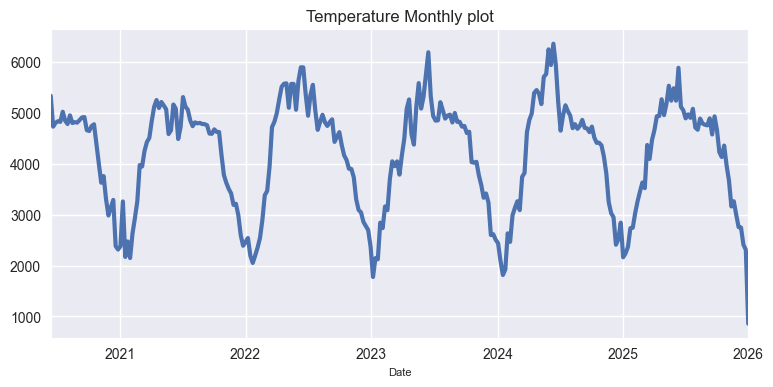

In [46]:
plot_feature("Temperature")

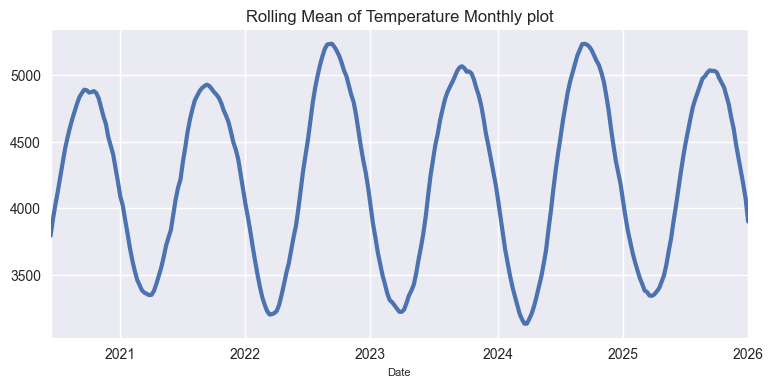

In [47]:
plot_feature("Rolling Mean of Temperature")

In [50]:
def decomposision(feature):
    
    docompose_additive_model = seasonal_decompose(feature , model = "additive" , period = 52)
    trend_additive = docompose_additive_model.trend
    seasonality_additive = docompose_additive_model.seasonal
    residual_additive = docompose_additive_model.resid

    plt.figure(figsize = (12,9))
    plt.subplot(411)
    plt.plot(feature , label = "original")
    plt.legend()
    plt.subplot(412)
    plt.plot(trend_additive , label = "trend")
    plt.legend()
    plt.subplot(413)
    plt.plot(seasonality_additive , label = "seasonality")
    plt.legend()
    plt.subplot(414)
    plt.plot(residual_additive , label = "residual")
    plt.legend()
    plt.show()
    

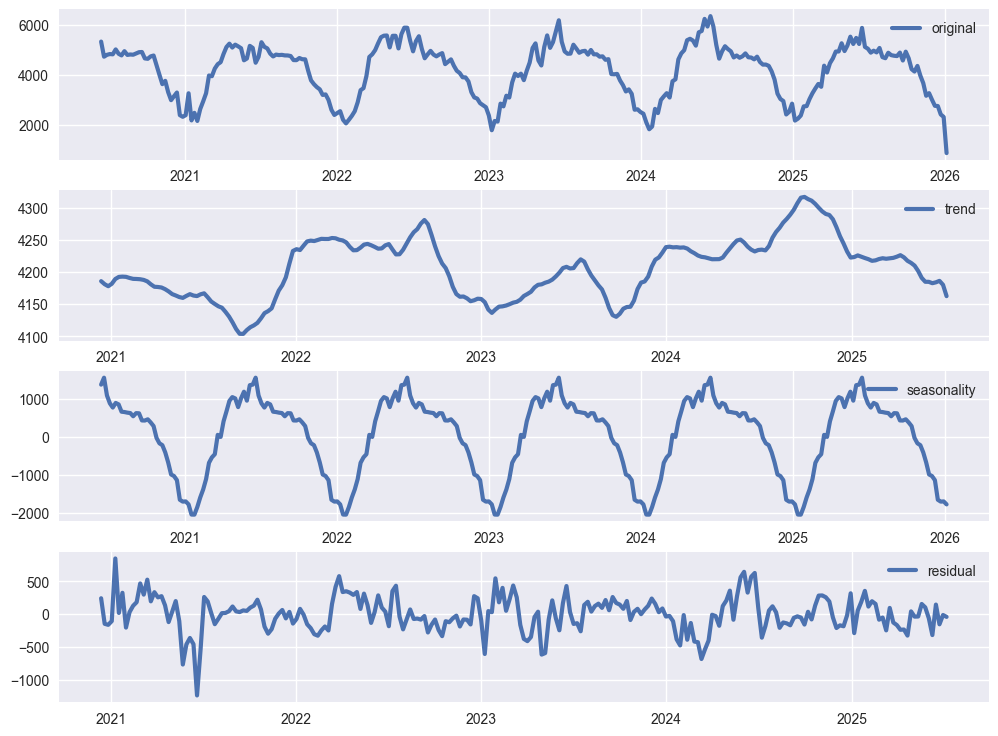

In [51]:
decomposision(weather_data["Temperature"])

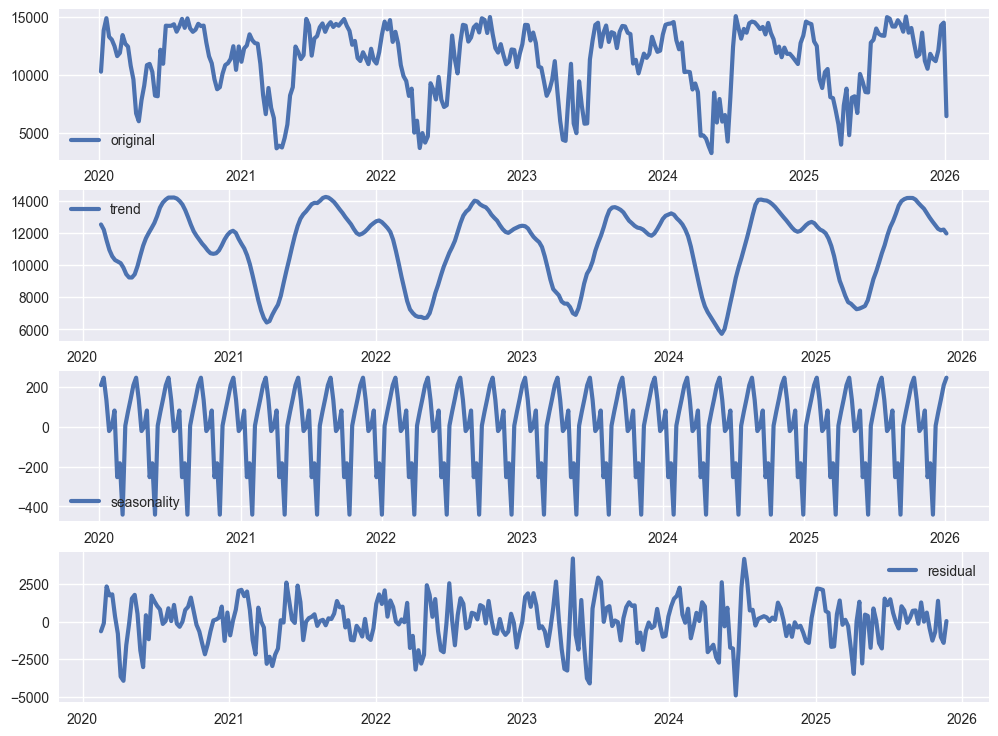

In [26]:
decomposision(weather_data["Relative_humidity"])

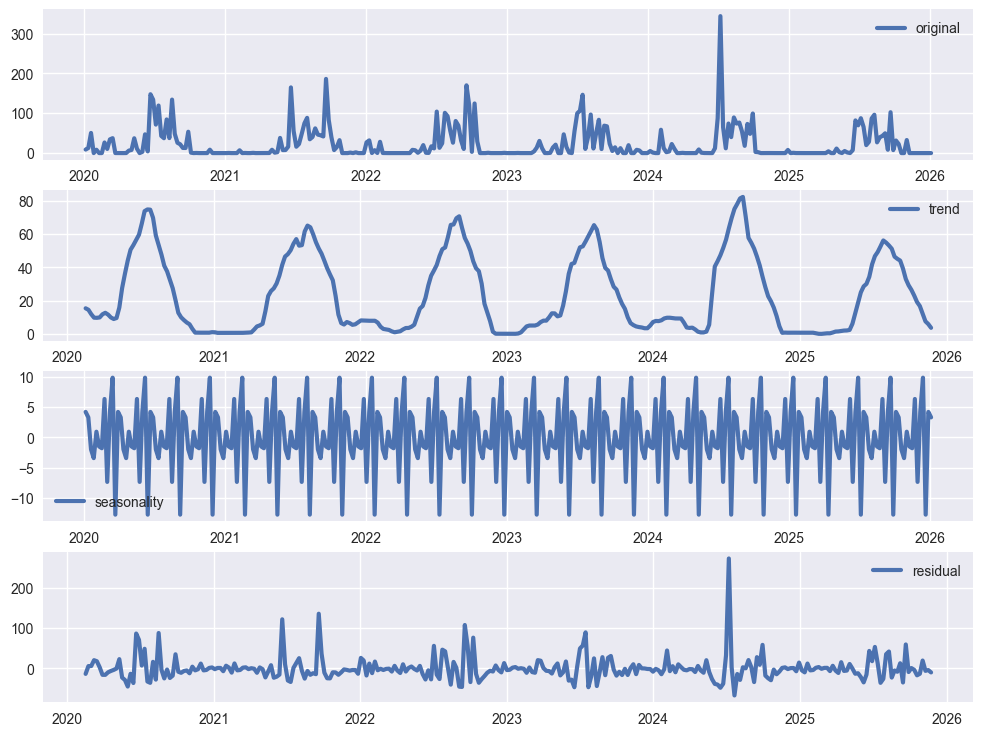

In [27]:
decomposision(weather_data["Rain"])

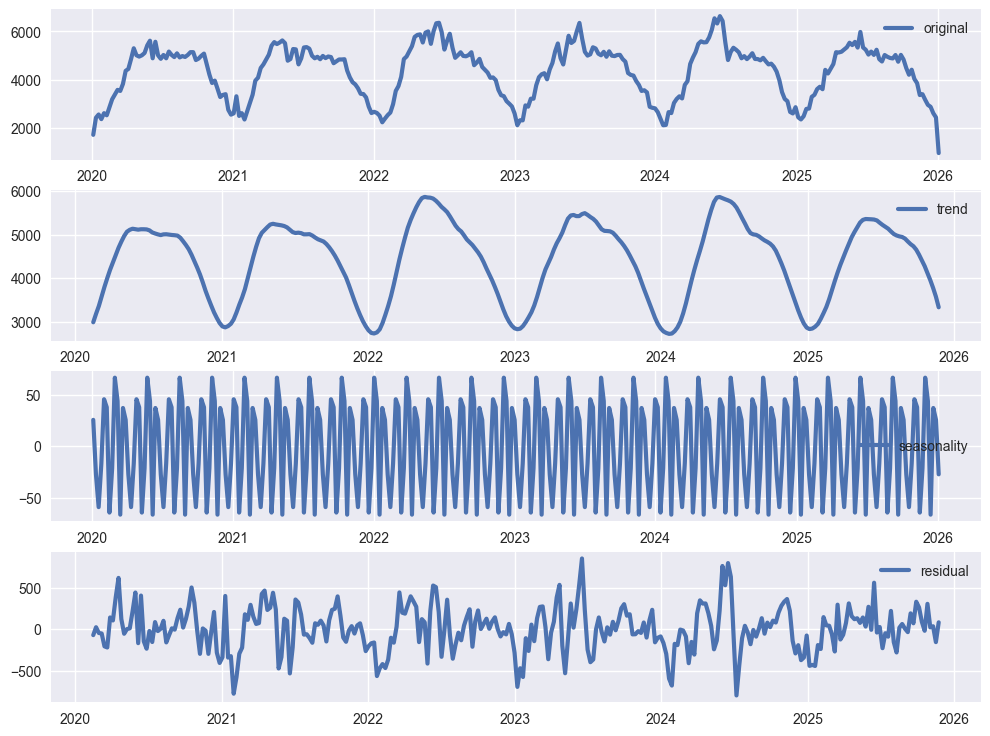

In [28]:
decomposision(weather_data["Soil_temperature"])

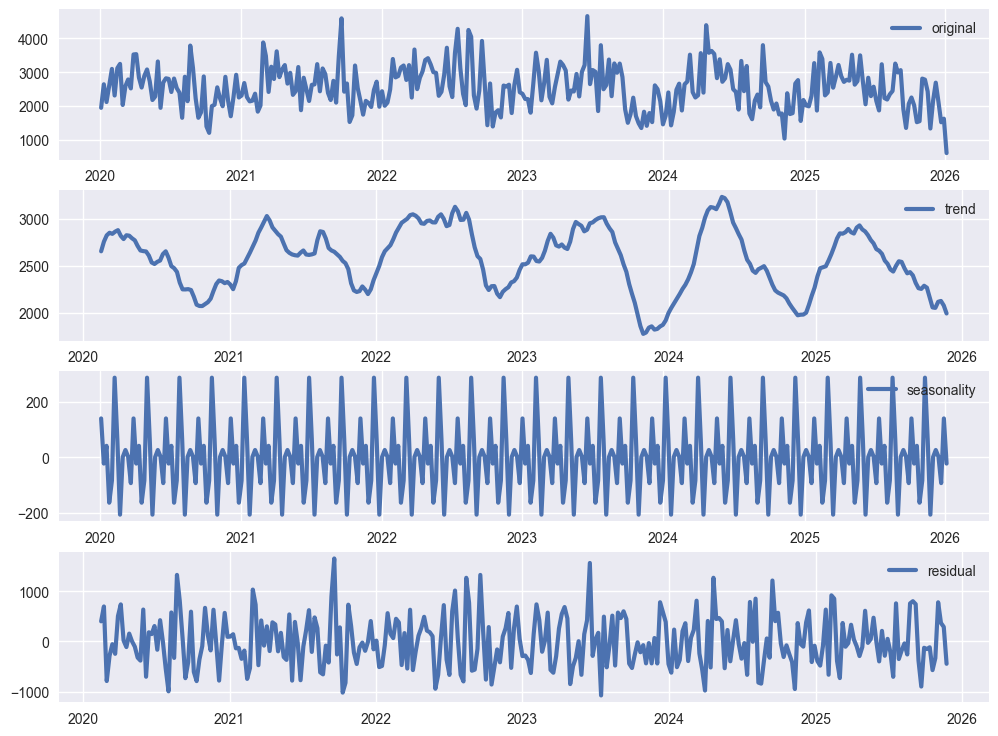

In [29]:
decomposision(weather_data["Wind_speed"])

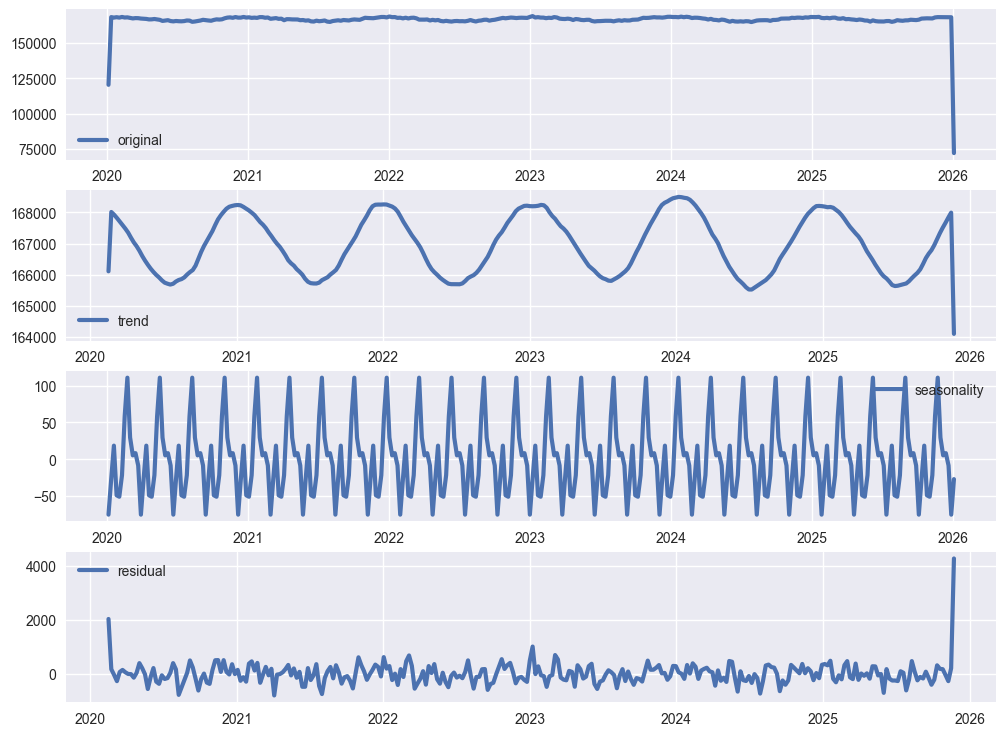

In [30]:
decomposision(weather_data["Surface_pressure"])

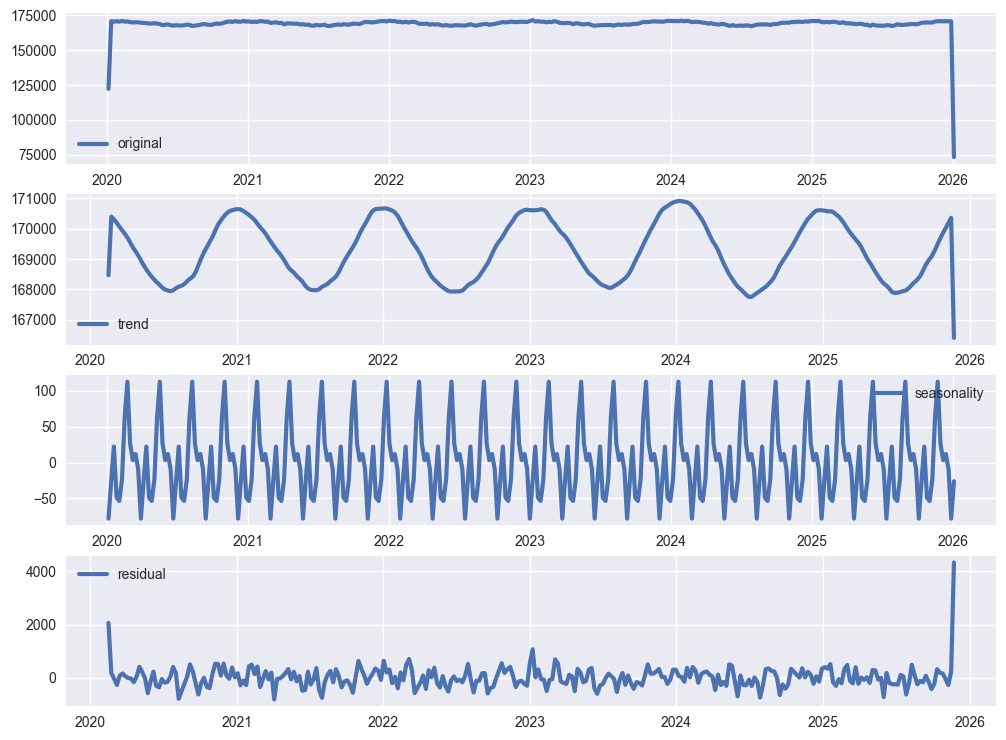

In [31]:
decomposision(weather_data["Pressure_msl"])

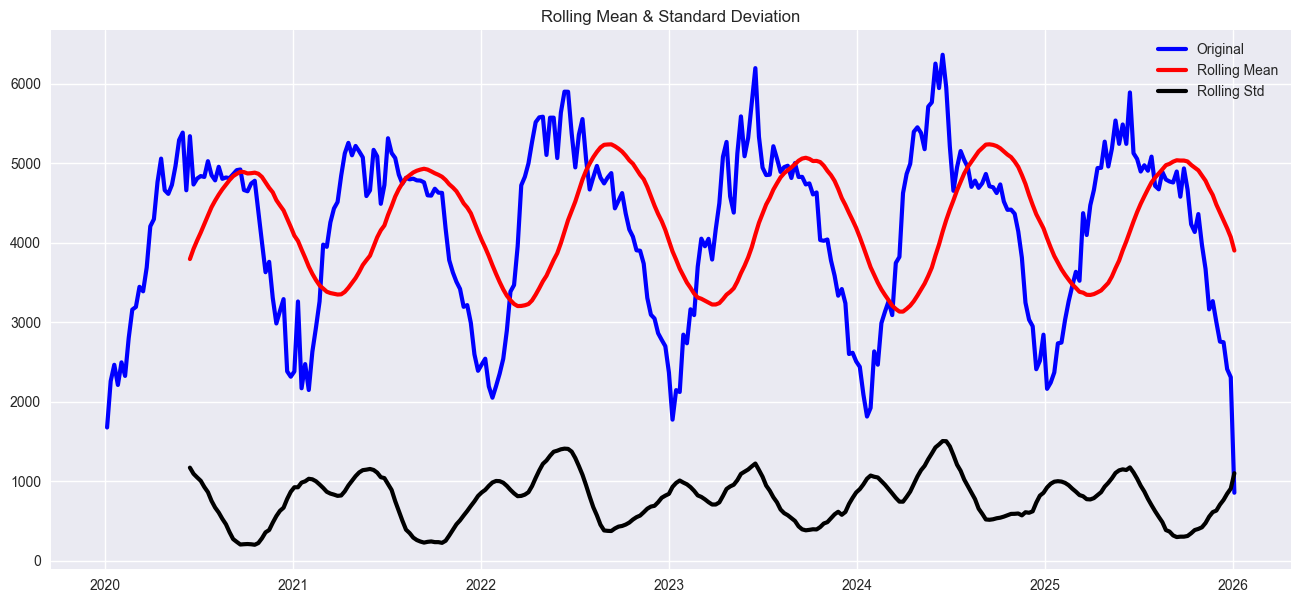

In [32]:
plt.figure(figsize=(16,7))
fig = plt.figure(1)

# Plot rolling statistics:
orig = plt.plot(weather_data["Temperature"], color='blue', label='Original')
mean = plt.plot(weather_data["Rolling Mean of Temperature"], color='red', label='Rolling Mean')
std = plt.plot(weather_data["Rolling std of Temperature"], color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

In [33]:
def stationarity_check(column_name):

    result = adfuller(column_name.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Number of Lags Used:", result[2])
    print("Number of Observations Used:", result[3])

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("The time series is Stationary (Reject the Null Hypothesis).")
    else:
        print("The time series is Non-Stationary (Fail to Reject the Null Hypothesis).")

In [34]:
stationarity_check(weather_data["Temperature"])

ADF Statistic: -5.024392053994605
p-value: 1.985405889797284e-05
Number of Lags Used: 10
Number of Observations Used: 303

Critical Values:
1%: -3.4521175397304784
5%: -2.8711265007266666
10%: -2.571877823851692
The time series is Stationary (Reject the Null Hypothesis).


In [35]:
stationarity_check(weather_data["Relative_humidity"])

ADF Statistic: -6.4333019754636265
p-value: 1.6765626546352357e-08
Number of Lags Used: 10
Number of Observations Used: 303

Critical Values:
1%: -3.4521175397304784
5%: -2.8711265007266666
10%: -2.571877823851692
The time series is Stationary (Reject the Null Hypothesis).


In [36]:
stationarity_check(weather_data["Rain"])

ADF Statistic: -4.55911496606718
p-value: 0.00015353877898035152
Number of Lags Used: 4
Number of Observations Used: 309

Critical Values:
1%: -3.45169128009473
5%: -2.8709394227049154
10%: -2.5717780602423517
The time series is Stationary (Reject the Null Hypothesis).


In [37]:
stationarity_check(weather_data["Soil_temperature"])

ADF Statistic: -4.9699001129154015
p-value: 2.5447415088112393e-05
Number of Lags Used: 11
Number of Observations Used: 302

Critical Values:
1%: -3.4521902441030963
5%: -2.871158406898617
10%: -2.5718948388228586
The time series is Stationary (Reject the Null Hypothesis).


In [38]:
stationarity_check(weather_data["Wind_speed"])

ADF Statistic: -4.370332964490193
p-value: 0.00033484882912874445
Number of Lags Used: 4
Number of Observations Used: 309

Critical Values:
1%: -3.45169128009473
5%: -2.8709394227049154
10%: -2.5717780602423517
The time series is Stationary (Reject the Null Hypothesis).


In [39]:
stationarity_check(weather_data["Surface_pressure"])

ADF Statistic: -8.734680599599713
p-value: 3.1233961097357896e-14
Number of Lags Used: 0
Number of Observations Used: 313

Critical Values:
1%: -3.4514162625887037
5%: -2.8708187088091406
10%: -2.5717136883095675
The time series is Stationary (Reject the Null Hypothesis).


In [40]:
stationarity_check(weather_data["Pressure_msl"])

ADF Statistic: -8.713116644023383
p-value: 3.546912280039274e-14
Number of Lags Used: 0
Number of Observations Used: 313

Critical Values:
1%: -3.4514162625887037
5%: -2.8708187088091406
10%: -2.5717136883095675
The time series is Stationary (Reject the Null Hypothesis).


In [41]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 314 entries, 2020-01-05 to 2026-01-04
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        314 non-null    float64
 1   Relative_humidity                  314 non-null    int64  
 2   Rain                               314 non-null    float64
 3   Soil_temperature                   314 non-null    float64
 4   Wind_speed                         314 non-null    float64
 5   Surface_pressure                   314 non-null    float64
 6   Pressure_msl                       314 non-null    float64
 7   is_day                             314 non-null    int64  
 8   Rolling Mean of Temperature        291 non-null    float64
 9   Rolling Mean of Relative_humidity  291 non-null    float64
 10  Rolling Mean of Rain               291 non-null    float64
 11  Rolling Mean of Soil_temperature   291 

In [42]:
type(weather_data)

pandas.core.frame.DataFrame

In [43]:
try:
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
    null_cols = [col for col in weather_data.columns if "Rolling" in col]
    weather_data = weather_data.dropna(subset=null_cols)
    weather_data = weather_data.drop(columns = ["Rolling Mean of is_day","Rolling std of is_day"])
    weather_data.to_csv("clean_weather_data.csv", index = True)
    print("file saved Successfully!")
except Exception as e:
    print("faild!")
    traceback.print_exc()

file saved Successfully!


In [44]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 291 entries, 2020-06-14 to 2026-01-04
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        291 non-null    float64
 1   Relative_humidity                  291 non-null    int64  
 2   Rain                               291 non-null    float64
 3   Soil_temperature                   291 non-null    float64
 4   Wind_speed                         291 non-null    float64
 5   Surface_pressure                   291 non-null    float64
 6   Pressure_msl                       291 non-null    float64
 7   is_day                             291 non-null    int64  
 8   Rolling Mean of Temperature        291 non-null    float64
 9   Rolling Mean of Relative_humidity  291 non-null    float64
 10  Rolling Mean of Rain               291 non-null    float64
 11  Rolling Mean of Soil_temperature   291 